In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned datasets
groundwater = pd.read_csv("groundwater_nitrate_clean.csv")
soils = pd.read_csv("soils_clean.csv")
prism = pd.read_csv("prism_climate_monthly_clean.csv")

In [2]:
groundwater.shape, soils.shape, prism.shape

((10665, 7), (15906, 9), (55014, 9))

**1. Groundwater target**

In [3]:
# Summary statistics for the target variable
groundwater["nitrate_mg_L"].describe()

count    10665.000000
mean        13.123557
std         21.049301
min          0.000000
25%          1.500000
50%          4.200000
75%         15.500000
max        230.000000
Name: nitrate_mg_L, dtype: float64

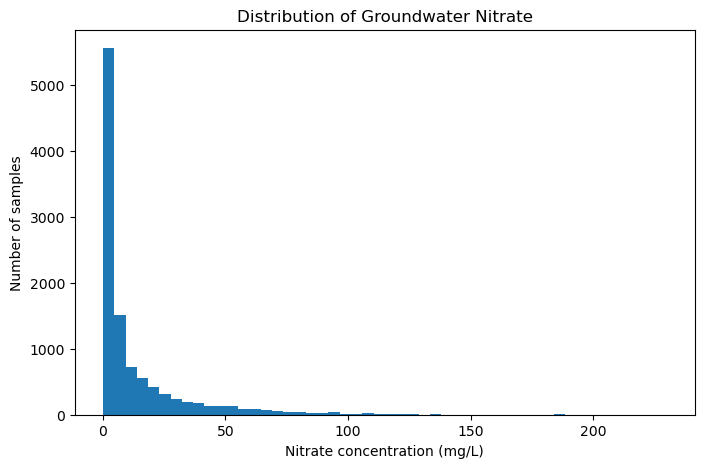

In [4]:
# Distribution of groundwater nitrate concentration
plt.figure(figsize=(8, 5))

plt.hist(
    groundwater["nitrate_mg_L"],
    bins=50
)

plt.xlabel("Nitrate concentration (mg/L)")
plt.ylabel("Number of samples")
plt.title("Distribution of Groundwater Nitrate")

plt.show()

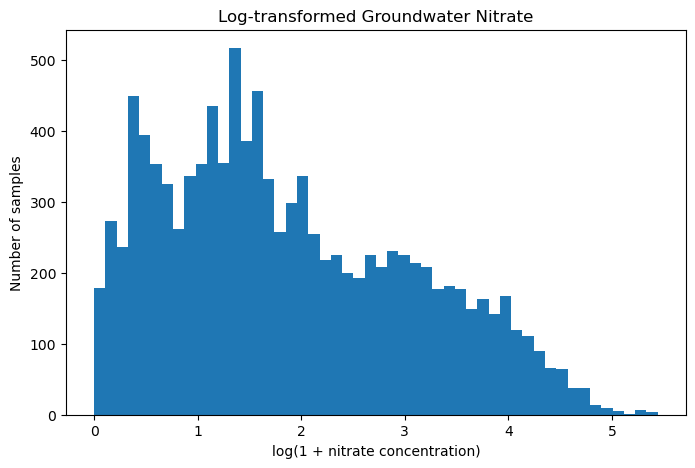

In [6]:
# Log-transform nitrate for exploration
import numpy as np
groundwater["log_nitrate"] = np.log1p(
    groundwater["nitrate_mg_L"]
)

plt.figure(figsize=(8, 5))

plt.hist(
    groundwater["log_nitrate"],
    bins=50
)

plt.xlabel("log(1 + nitrate concentration)")
plt.ylabel("Number of samples")
plt.title("Log-transformed Groundwater Nitrate")

plt.show()

In [7]:
# Number of observations per well
well_counts = (
    groundwater
    .groupby("gm_well_id")
    .size()
    .sort_values(ascending=False)
)

well_counts.describe()

count    3245.000000
mean        3.286595
std         2.711092
min         1.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        30.000000
dtype: float64

In [8]:
well_counts.head(10)

gm_well_id
AGL020017603-GH18-03       30
AGL020017603-GH18-02       29
AGL020017603-GH18-01       28
AGL020007536-GH16-15       27
AGL020007538-GH15-02       27
AGL020007540-GH12-09       26
AGL020007533-GH20-07       25
AGL020017603-GH18-DOM      25
AGL020004022-GABILAN W1    25
AGL020007541-GH21-215      24
dtype: int64

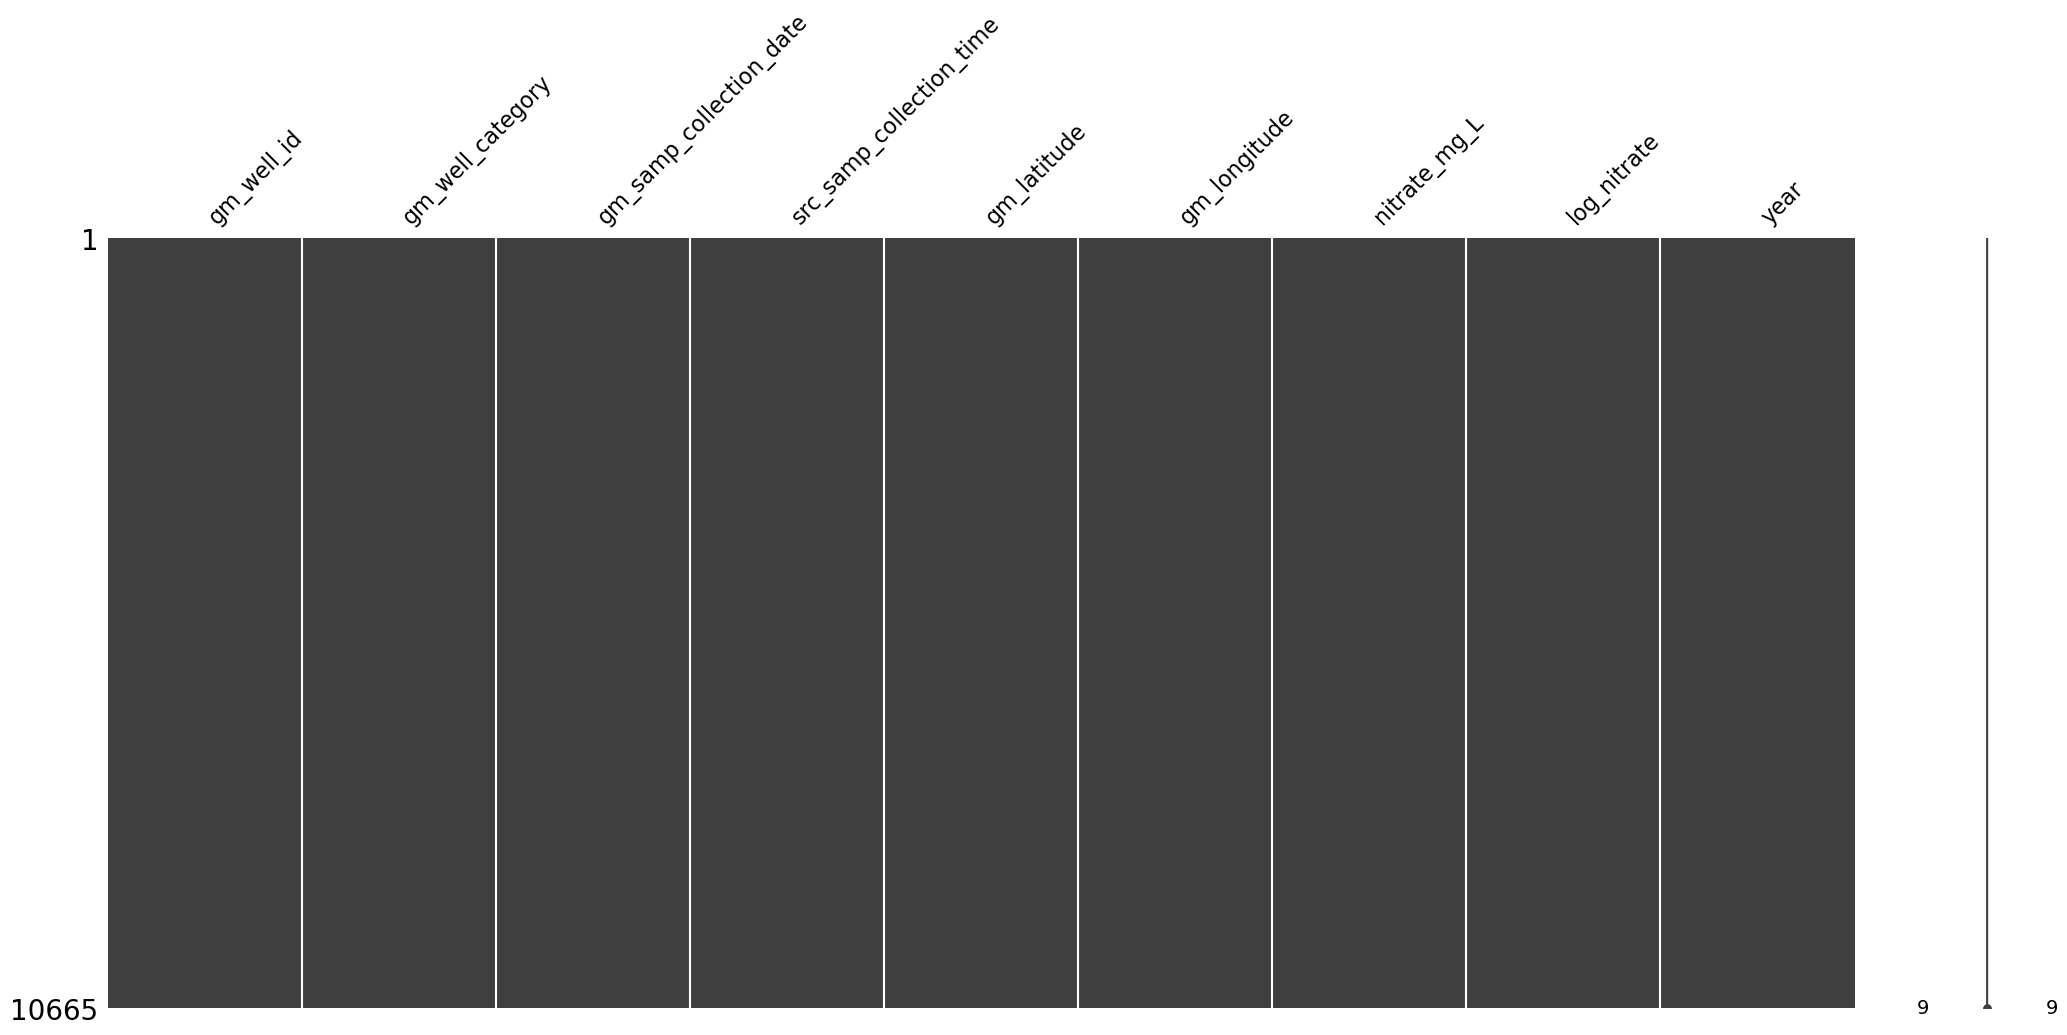

In [11]:
import missingno as msno
# Visualize missing values
msno.matrix(groundwater)

plt.show()

In [10]:
# Convert sampling date to datetime
groundwater["gm_samp_collection_date"] = pd.to_datetime(
    groundwater["gm_samp_collection_date"]
)

# Samples per year
groundwater["year"] = groundwater["gm_samp_collection_date"].dt.year

samples_by_year = groundwater.groupby("year").size()

samples_by_year

year
2010       1
2011       1
2012     382
2013     708
2014     457
2015     267
2016     130
2017    2147
2018     349
2019     551
2020     232
2021     154
2022    1459
2023    1298
2024    1252
2025    1277
dtype: int64

<Figure size 1000x500 with 0 Axes>

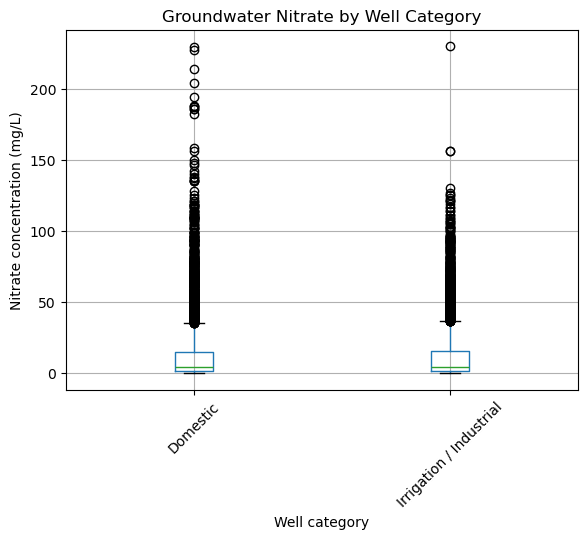

In [12]:
# Groundwater nitrate by well category
plt.figure(figsize=(10, 5))

groundwater.boxplot(
    column="nitrate_mg_L",
    by="gm_well_category",
    rot=45
)

plt.title("Groundwater Nitrate by Well Category")
plt.suptitle("")
plt.xlabel("Well category")
plt.ylabel("Nitrate concentration (mg/L)")

plt.show()

In [14]:
# Count samples by well category
groundwater["gm_well_category"].value_counts()

gm_well_category
Irrigation / Industrial    6028
Domestic                   4637
Name: count, dtype: int64

In [15]:
# Summary statistics by well category
groundwater.groupby("gm_well_category")["nitrate_mg_L"].describe()

,count,mean,std,min,25%,50%,75%,max
gm_well_category,,,,,,,,
Domestic,4637.0,13.862899,23.590677,0.0,1.44,4.1000,14.9,229.0
Irrigation / Industrial,6028.0,12.554823,18.845118,0.0,1.60,4.2175,15.7,230.0


In [16]:
# Count high nitrate observations
high_nitrate_counts = {
    "> 50 mg/L": (groundwater["nitrate_mg_L"] > 50).sum(),
    "> 100 mg/L": (groundwater["nitrate_mg_L"] > 100).sum(),
    "> 150 mg/L": (groundwater["nitrate_mg_L"] > 150).sum()
}

high_nitrate_counts

{'> 50 mg/L': np.int64(716),
 '> 100 mg/L': np.int64(99),
 '> 150 mg/L': np.int64(16)}

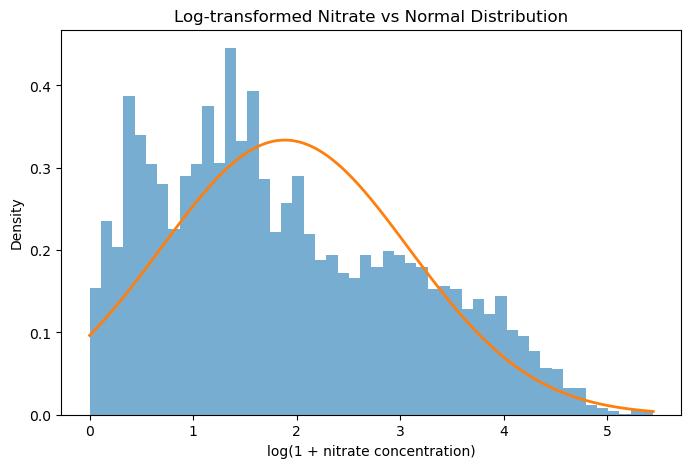

In [18]:
# Compare log-transformed nitrate with a normal curve
x = groundwater["log_nitrate"]

plt.figure(figsize=(8, 5))

plt.hist(
    x,
    bins=50,
    density=True,
    alpha=0.6
)

x_values = np.linspace(x.min(), x.max(), 500)

normal_curve = norm.pdf(
    x_values,
    loc=x.mean(),
    scale=x.std()
)

plt.plot(
    x_values,
    normal_curve,
    linewidth=2
)

plt.xlabel("log(1 + nitrate concentration)")
plt.ylabel("Density")
plt.title("Log-transformed Nitrate vs Normal Distribution")

plt.show()

**2. Soil predictors**


In [20]:
# Missing values in soil data
soils.isna().sum()

AREASYMBOL         0
SPATIALVER         0
MUSYM              0
MUKEY              0
slopegradwta       8
brockdepmin     6910
aws0150wta       655
drclassdcd      1594
hydgrpdcd       1122
dtype: int64

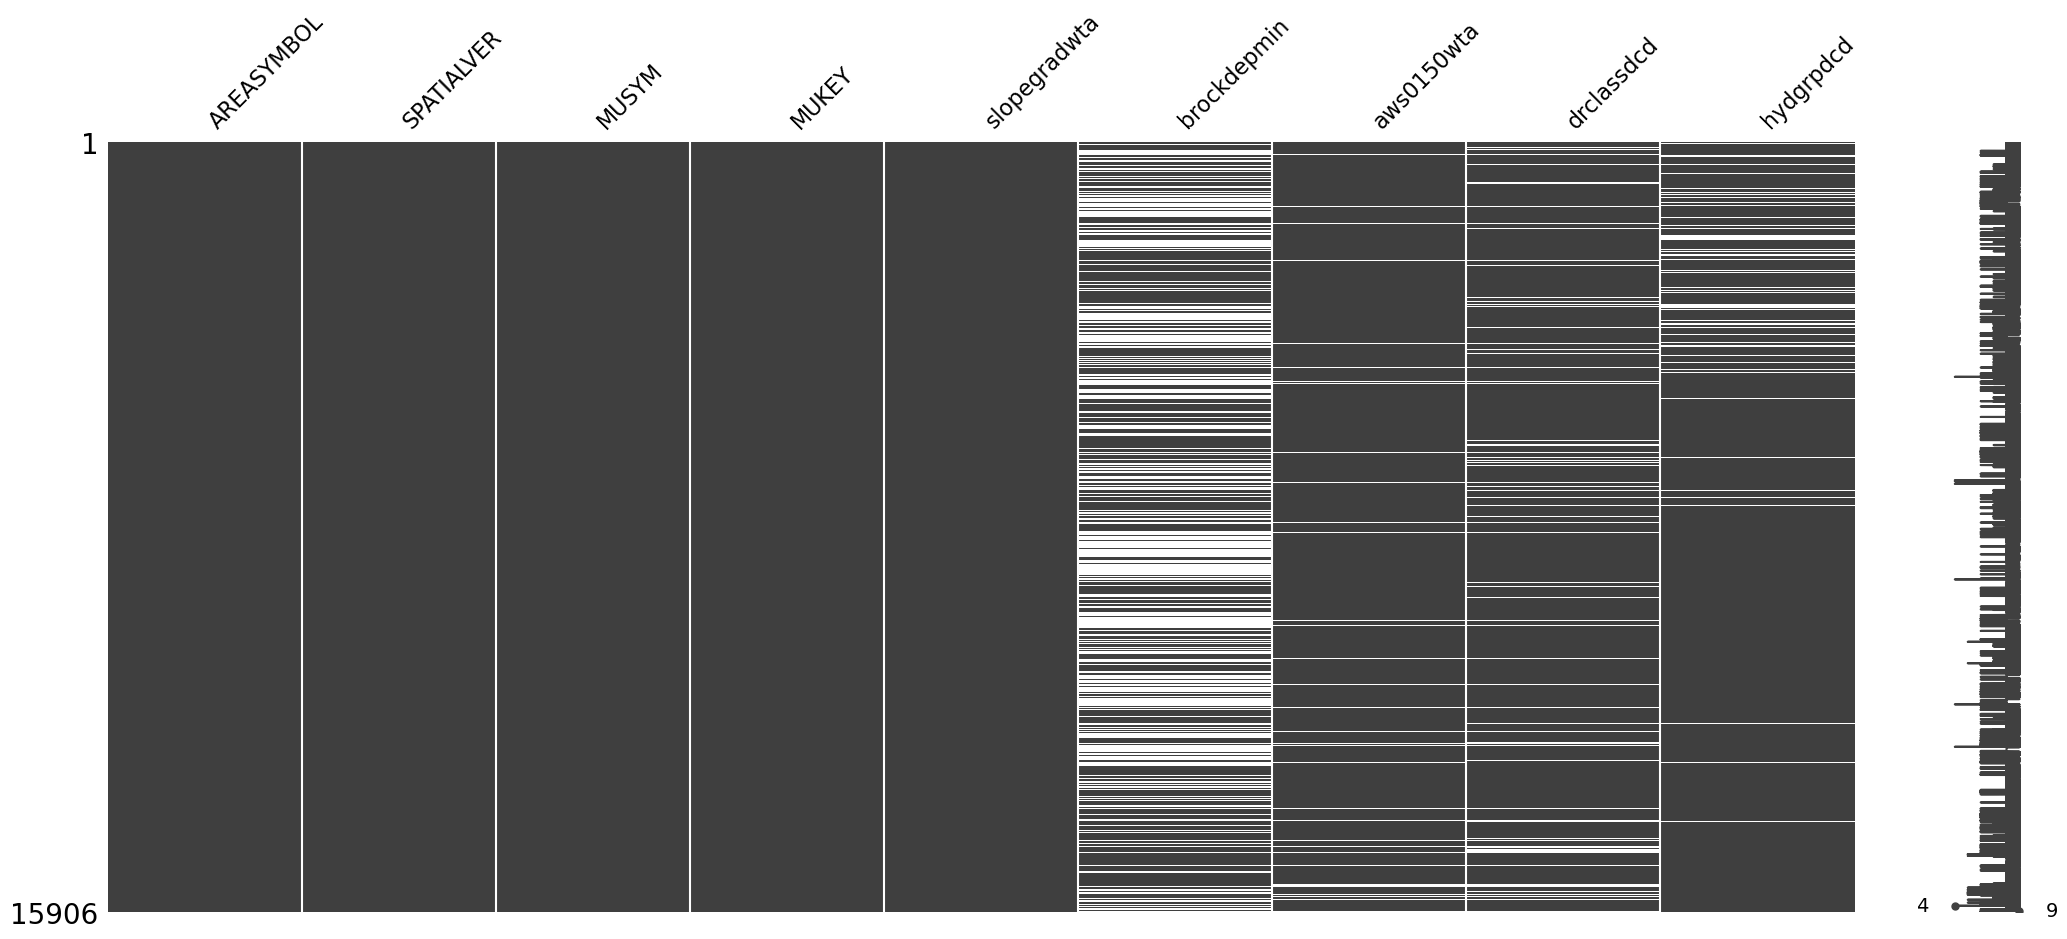

In [21]:
# Visualize missing values in soil data
msno.matrix(soils)

plt.show()

In [22]:
# Percentage of missing values
soil_missing_percent = (
    soils.isna().mean() * 100
).sort_values(ascending=False)

soil_missing_percent

brockdepmin     43.442726
drclassdcd      10.021376
hydgrpdcd        7.053942
aws0150wta       4.117943
slopegradwta     0.050295
AREASYMBOL       0.000000
MUKEY            0.000000
SPATIALVER       0.000000
MUSYM            0.000000
dtype: float64

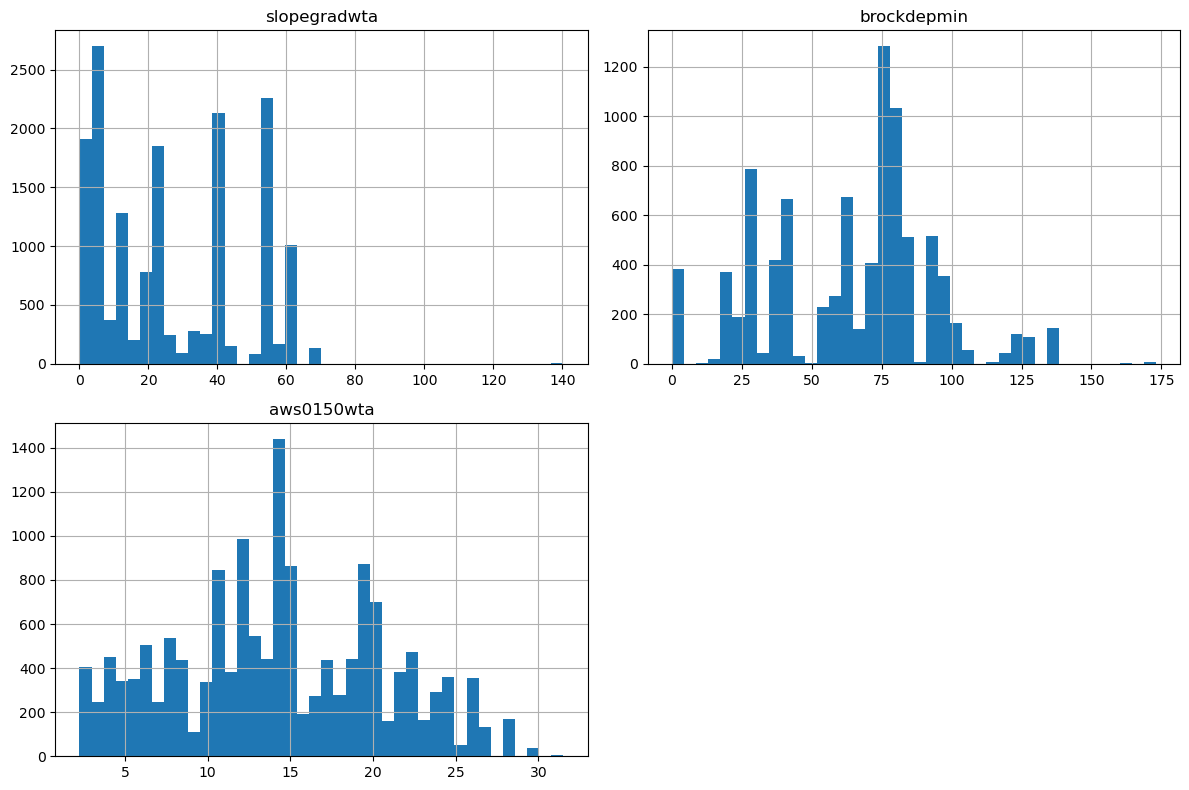

In [23]:
# Distribution of numeric soil variables
soil_numeric = [
    "slopegradwta",
    "brockdepmin",
    "aws0150wta"
]

soils[soil_numeric].hist(
    bins=40,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

In [24]:
# Soil drainage classes
soils["drclassdcd"].value_counts(dropna=False)

drclassdcd
Well drained                    12404
NaN                              1594
Somewhat excessively drained     1332
Moderately well drained           315
Excessively drained               138
Poorly drained                     80
Somewhat poorly drained            37
Very poorly drained                 6
Name: count, dtype: int64

In [25]:
# Hydrologic soil groups
soils["hydgrpdcd"].value_counts(dropna=False)

hydgrpdcd
C      7374
D      3971
B      1939
A      1490
NaN    1122
C/D      10
Name: count, dtype: int64

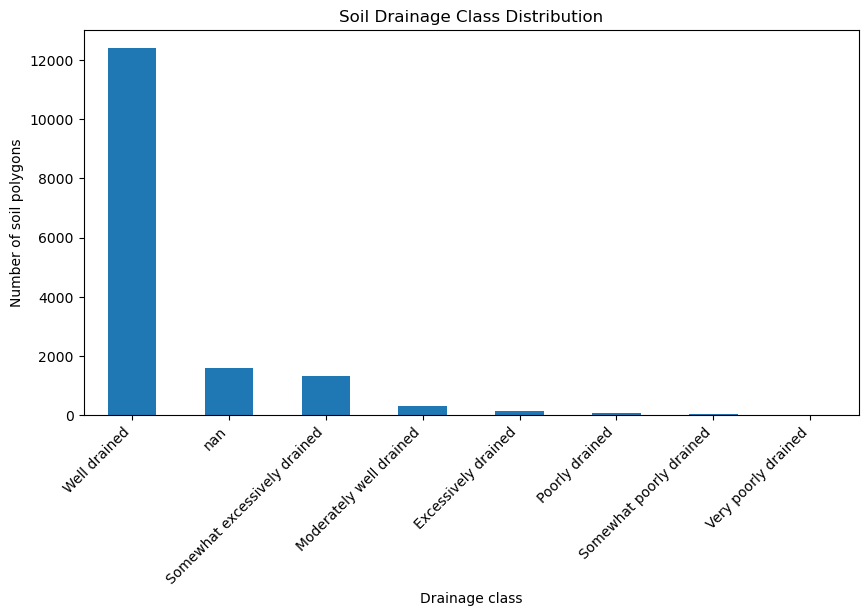

In [26]:
# Drainage class distribution
soils["drclassdcd"].value_counts(dropna=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Drainage class")
plt.ylabel("Number of soil polygons")
plt.title("Soil Drainage Class Distribution")
plt.xticks(rotation=45, ha="right")

plt.show()

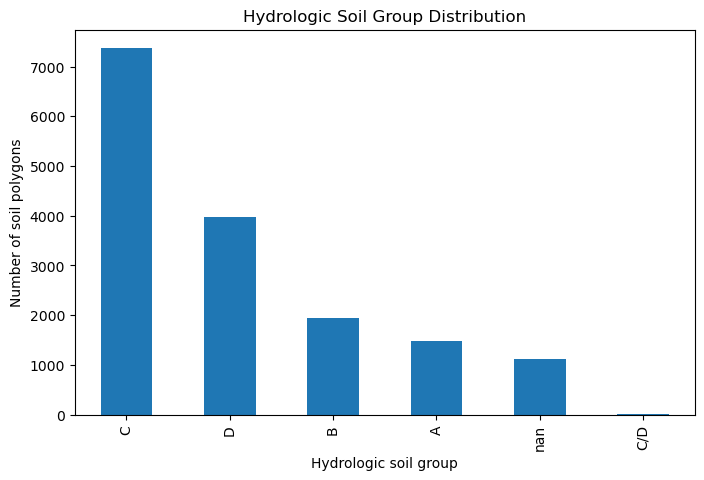

In [27]:
# Hydrologic soil group distribution
soils["hydgrpdcd"].value_counts(dropna=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Hydrologic soil group")
plt.ylabel("Number of soil polygons")
plt.title("Hydrologic Soil Group Distribution")

plt.show()

**3. Climate predictors**


In [28]:
# Basic precipitation summary
prism["precip_in"].describe()

count    55014.000000
mean         1.441166
std          2.660624
min          0.000000
25%          0.000000
50%          0.200000
75%          1.740000
max         42.570000
Name: precip_in, dtype: float64

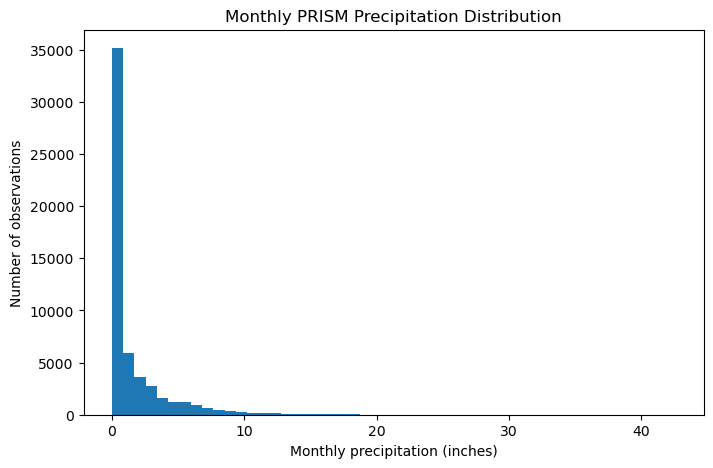

In [29]:
# Distribution of monthly precipitation
plt.figure(figsize=(8, 5))

plt.hist(
    prism["precip_in"],
    bins=50
)

plt.xlabel("Monthly precipitation (inches)")
plt.ylabel("Number of observations")
plt.title("Monthly PRISM Precipitation Distribution")

plt.show()

In [30]:
# Check missing values
prism.isna().sum()

point_id        0
longitude       0
latitude        0
elevation_ft    0
date            0
precip_in       0
tmean_f         0
year            0
month           0
dtype: int64

In [31]:
# Check temporal coverage
prism["date"] = pd.to_datetime(prism["date"])

print(prism["date"].min())
print(prism["date"].max())
print(prism["point_id"].nunique())

2013-01-01 00:00:00
2026-03-01 00:00:00
346


In [32]:
# Average precipitation by month
monthly_precip = (
    prism
    .groupby("month")["precip_in"]
    .mean()
)

monthly_precip

month
1     3.855974
2     3.068918
3     2.982128
4     0.806172
5     0.267059
6     0.027041
7     0.046450
8     0.008704
9     0.114604
10    0.521910
11    1.607328
12    3.558204
Name: precip_in, dtype: float64

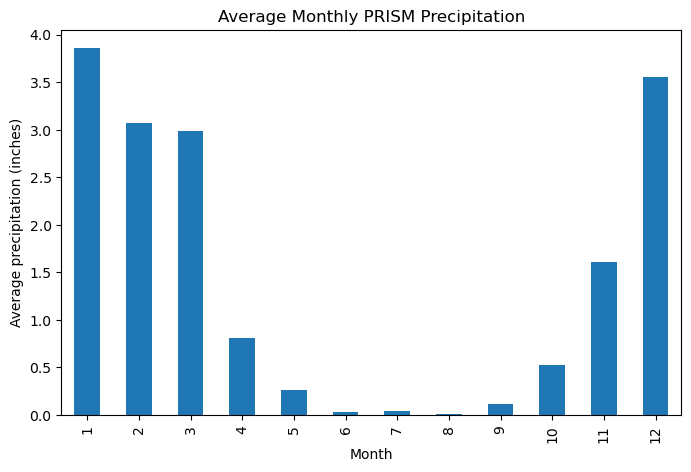

In [33]:
plt.figure(figsize=(8, 5))

monthly_precip.plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Average precipitation (inches)")
plt.title("Average Monthly PRISM Precipitation")

plt.show()

**4. Missingness summary**


In [39]:
# Clean missingness summary for each dataset
groundwater_missing = pd.DataFrame({
    "feature": groundwater.columns,
    "missing_count": groundwater.isna().sum().values,
    "missing_percent": (groundwater.isna().mean().values * 100)
})

soils_missing = pd.DataFrame({
    "feature": soils.columns,
    "missing_count": soils.isna().sum().values,
    "missing_percent": (soils.isna().mean().values * 100)
})

prism_missing = pd.DataFrame({
    "feature": prism.columns,
    "missing_count": prism.isna().sum().values,
    "missing_percent": (prism.isna().mean().values * 100)
})

In [40]:
groundwater_missing

,feature,missing_count,missing_percent
0,gm_well_id,0,0.0
1,gm_well_category,0,0.0
2,gm_samp_collection_date,0,0.0
3,src_samp_collection_time,0,0.0
4,gm_latitude,0,0.0
5,gm_longitude,0,0.0
6,nitrate_mg_L,0,0.0
7,log_nitrate,0,0.0
8,year,0,0.0


In [41]:
soils_missing.sort_values(
    "missing_percent",
    ascending=False
)

,feature,missing_count,missing_percent
5,brockdepmin,6910,43.442726
7,drclassdcd,1594,10.021376
8,hydgrpdcd,1122,7.053942
6,aws0150wta,655,4.117943
4,slopegradwta,8,0.050295
0,AREASYMBOL,0,0.000000
3,MUKEY,0,0.000000
1,SPATIALVER,0,0.000000
2,MUSYM,0,0.000000


In [42]:
prism_missing

,feature,missing_count,missing_percent
0,point_id,0,0.0
1,longitude,0,0.0
2,latitude,0,0.0
3,elevation_ft,0,0.0
4,date,0,0.0
5,precip_in,0,0.0
6,tmean_f,0,0.0
7,year,0,0.0
8,month,0,0.0


In [ ]:
5. Distribution plots

In [ ]:
6. Initial feature decisions

In [43]:
# Initial feature selection decisions

feature_selection = pd.DataFrame({
    "feature": [
        "nitrate_mg_L",
        "log_nitrate",
        "gm_well_category",
        "gm_well_id",
        "year",
        "slopegradwta",
        "brockdepmin",
        "aws0150wta",
        "drclassdcd",
        "hydgrpdcd",
        "precip_in",
        "tmean_f"
    ],
    "decision": [
        "target",
        "explore",
        "keep",
        "drop",
        "explore",
        "keep",
        "keep/review",
        "keep",
        "keep",
        "keep",
        "keep",
        "drop"
    ],
    "reason": [
        "Primary prediction target",
        "Alternative transformed target due to strong right skew",
        "Potential well-type effect",
        "Identifier only; risk of leakage",
        "Explore temporal variation; not necessarily a final predictor",
        "Plausible topographic/soil control",
        "Potential hydrogeologic relevance but 43% missing",
        "Soil water storage capacity",
        "Drainage behavior",
        "Infiltration/runoff behavior",
        "Primary climate predictor",
        "Not included in initial climate model"
    ]
})

feature_selection

,feature,decision,reason
0,nitrate_mg_L,target,Primary prediction target
1,log_nitrate,explore,Alternative transformed target due to strong r...
2,gm_well_category,keep,Potential well-type effect
3,gm_well_id,drop,Identifier only; risk of leakage
4,year,explore,Explore temporal variation; not necessarily a ...
5,slopegradwta,keep,Plausible topographic/soil control
6,brockdepmin,keep/review,Potential hydrogeologic relevance but 43% missing
7,aws0150wta,keep,Soil water storage capacity
8,drclassdcd,keep,Drainage behavior
9,hydgrpdcd,keep,Infiltration/runoff behavior


In [ ]:
#precip_in | keep / engineer | Base climate variable; will be transformed into lagged precipitation features

In [45]:
# Save initial feature selection decisions
feature_selection.to_csv(
    "feature_selection.csv",
    index=False
)